# Tugas Akhir Kecerdasan Buatan

## Kelompok 1:
- Alfonsus Tanara Gultom (2306267126)
- Farhan Ramadhani Zakiyyandi (2306220412)
- Naufal Febriyanto (2106702674)
- Filaga Tifira Muthi (2306280445)

Setup & Instalasi Lingkungan

In [1]:
# Install sistem fisik Box2D dan library Gymnasium
!apt-get install -y swig
!pip install gymnasium[box2d] torch numpy matplotlib pandas

import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt

# Cek apakah pakai GPU atau CPU Colab
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {device}")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  swig4.0
Suggested packages:
  swig-doc swig-examples swig4.0-examples swig4.0-doc
The following NEW packages will be installed:
  swig swig4.0
0 upgraded, 2 newly installed, 0 to remove and 51 not upgraded.
Need to get 1,116 kB of archives.
After this operation, 5,542 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 swig4.0 amd64 4.0.2-1ubuntu1 [1,110 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 swig all 4.0.2-1ubuntu1 [5,632 B]
Fetched 1,116 kB in 0s (16.2 MB/s)
Selecting previously unselected package swig4.0.
(Reading database ... 122412 files and directories currently installed.)
Preparing to unpack .../swig4.0_4.0.2-1ubuntu1_amd64.deb ...
Unpacking swig4.0 (4.0.2-1ubuntu1) ...
Selecting previously unselected package swig.
Preparing to unpack .../swig_4.0.2-1ubun

Evaluasi Baseline Random

In [3]:
# Membuat environment roket
env_baseline = gym.make("LunarLander-v3")

baseline_rewards = []
print("--- MENGUJI BOT RANDOM (BASELINE) ---")

for episode in range(10): # Tes 10 kali penerbangan
    state, info = env_baseline.reset()
    total_reward = 0
    done = False
    truncated = False

    while not (done or truncated):
        # Milih tombol acak (0, 1, 2, atau 3)
        action = env_baseline.action_space.sample()
        next_state, reward, done, truncated, info = env_baseline.step(action)
        total_reward += reward

    baseline_rewards.append(total_reward)
    print(f"Penerbangan {episode+1}: Poin = {total_reward:.2f} (Roket Meledak/Jatuh)")

avg_baseline = np.mean(baseline_rewards)
print(f"\nRATA-RATA POIN BASELINE: {avg_baseline:.2f}")
env_baseline.close()

--- MENGUJI BOT RANDOM (BASELINE) ---
Penerbangan 1: Poin = -154.45 (Roket Meledak/Jatuh)
Penerbangan 2: Poin = -173.48 (Roket Meledak/Jatuh)
Penerbangan 3: Poin = -629.60 (Roket Meledak/Jatuh)
Penerbangan 4: Poin = -124.60 (Roket Meledak/Jatuh)
Penerbangan 5: Poin = -250.27 (Roket Meledak/Jatuh)
Penerbangan 6: Poin = -177.11 (Roket Meledak/Jatuh)
Penerbangan 7: Poin = -248.06 (Roket Meledak/Jatuh)
Penerbangan 8: Poin = -93.43 (Roket Meledak/Jatuh)
Penerbangan 9: Poin = -143.96 (Roket Meledak/Jatuh)
Penerbangan 10: Poin = -490.65 (Roket Meledak/Jatuh)

RATA-RATA POIN BASELINE: -248.56


Arsitektur Otak AI

In [4]:
class QNetwork(nn.Module):
    def __init__(self, state_size=8, action_size=4):
        super(QNetwork, self).__init__()
        # Arsitektur: 8 Input -> 64 Hidden -> 64 Hidden -> 4 Output (Aksi)
        self.fc1 = nn.Linear(state_size, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_size)

    def forward(self, state):
        x = torch.relu(self.fc1(state))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# Replay Buffer: Buku harian (memori) tempat AI mengingat pengalamannya
class ReplayBuffer:
    def __init__(self, capacity=100000):
        self.memory = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.memory, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (np.array(states), np.array(actions), np.array(rewards),
                np.array(next_states), np.array(dones))

    def __len__(self):
        return len(self.memory)

# Pengaturan penting untuk dosen:
BATCH_SIZE = 64        # Berapa memori yang dipelajari dalam 1 waktu
GAMMA = 0.99           # Seberapa AI peduli pada masa depan (discount factor)
LR = 5e-4              # Kecepatan belajar (Learning rate)
TARGET_UPDATE = 4      # Kapan AI mencontek kunci jawaban
EPISODES = 500         # BERAPA KALI ROKET TERBANG (Bisa dinaikkan kalau masih bodoh)

# Inisialisasi Environment & Otak AI
env = gym.make("LunarLander-v3")
state_size = env.observation_space.shape[0]
action_size = env.action_space.n

# Kita butuh 2 jaringan agar belajarnya stabil (Policy Net dan Target Net)
policy_net = QNetwork(state_size, action_size).to(device)
target_net = QNetwork(state_size, action_size).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval() # Target net tidak di-train langsung

optimizer = optim.Adam(policy_net.parameters(), lr=LR)
memory = ReplayBuffer()

PROSES TRAINING UTAMA

In [5]:
# Parameter Eksplorasi (Epsilon Greedy)
epsilon = 1.0          # 100% Acak di awal
epsilon_min = 0.01     # Paling kecil 1% acak di akhir
epsilon_decay = 0.995  # Pengurangan sifat acak per episode

reward_history = []

print("MEMULAI TRAINING ROKET")

for episode in range(EPISODES):
    state, _ = env.reset()
    total_reward = 0
    done = False
    truncated = False

    while not (done or truncated):
        # 1. Pilih Aksi (Pakai AI atau Acak)
        if random.random() <= epsilon:
            action = env.action_space.sample() # Acak (Eksplorasi)
        else:
            with torch.no_grad(): # Pakai otak pintar (Eksploitasi)
                state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
                q_values = policy_net(state_tensor)
                action = q_values.argmax().item()

        # 2. Lakukan Aksi di dunia nyata
        next_state, reward, done, truncated, _ = env.step(action)
        total_reward += reward

        # 3. Simpan ke Buku Harian (Memori)
        memory.push(state, action, reward, next_state, done or truncated)
        state = next_state

        # 4. Fase Belajar (Membaca buku harian)
        if len(memory) > BATCH_SIZE:
            states, actions, rewards, next_states, dones = memory.sample(BATCH_SIZE)

            # Ubah ke format PyTorch Tensor
            states = torch.FloatTensor(states).to(device)
            actions = torch.LongTensor(actions).unsqueeze(1).to(device)
            rewards = torch.FloatTensor(rewards).unsqueeze(1).to(device)
            next_states = torch.FloatTensor(next_states).to(device)
            dones = torch.FloatTensor(dones).unsqueeze(1).to(device)

            # Hitung Rumus DQN (Q-Learning)
            curr_Q = policy_net(states).gather(1, actions)
            next_Q = target_net(next_states).max(1)[0].unsqueeze(1)
            expected_Q = rewards + (GAMMA * next_Q * (1 - dones))

            loss = nn.MSELoss()(curr_Q, expected_Q)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # Update Target Network (Agar stabil)
    if episode % TARGET_UPDATE == 0:
        target_net.load_state_dict(policy_net.state_dict())

    # Kurangi sifat acak seiring waktu
    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    reward_history.append(total_reward)

    if (episode + 1) % 50 == 0:
        avg_last_50 = np.mean(reward_history[-50:])
        print(f"Episode {episode+1}/{EPISODES} | Rata-rata Poin 50 terakhir: {avg_last_50:.2f} | Epsilon: {epsilon:.2f}")

print("TRAINING SELESAI")

MEMULAI TRAINING ROKET
Episode 50/500 | Rata-rata Poin 50 terakhir: -156.06 | Epsilon: 0.78
Episode 100/500 | Rata-rata Poin 50 terakhir: -102.95 | Epsilon: 0.61
Episode 150/500 | Rata-rata Poin 50 terakhir: -55.74 | Epsilon: 0.47
Episode 200/500 | Rata-rata Poin 50 terakhir: -94.17 | Epsilon: 0.37
Episode 250/500 | Rata-rata Poin 50 terakhir: -45.47 | Epsilon: 0.29
Episode 300/500 | Rata-rata Poin 50 terakhir: -38.00 | Epsilon: 0.22
Episode 350/500 | Rata-rata Poin 50 terakhir: -22.91 | Epsilon: 0.17
Episode 400/500 | Rata-rata Poin 50 terakhir: -20.74 | Epsilon: 0.13
Episode 450/500 | Rata-rata Poin 50 terakhir: 106.17 | Epsilon: 0.10
Episode 500/500 | Rata-rata Poin 50 terakhir: 129.45 | Epsilon: 0.08
TRAINING SELESAI


Visualisasi Grafik

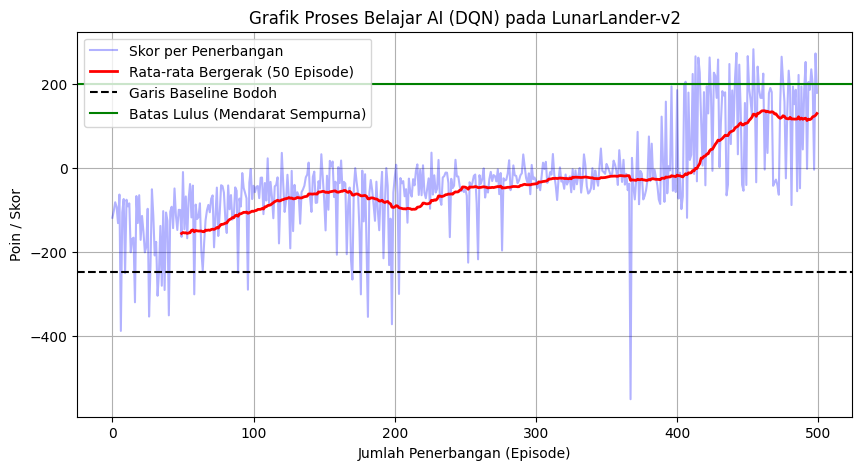

In [6]:
import pandas as pd

plt.figure(figsize=(10,5))
plt.plot(reward_history, label='Skor per Penerbangan', alpha=0.3, color='blue')

# Bikin garis tebal (Moving Average) biar kelihatan tren naiknya
smoothed_rewards = pd.Series(reward_history).rolling(window=50).mean()
plt.plot(smoothed_rewards, label='Rata-rata Bergerak (50 Episode)', color='red', linewidth=2)

plt.axhline(y=avg_baseline, color='black', linestyle='--', label='Garis Baseline Bodoh')
plt.axhline(y=200, color='green', linestyle='-', label='Batas Lulus (Mendarat Sempurna)')

plt.title('Grafik Proses Belajar AI (DQN) pada LunarLander-v2')
plt.xlabel('Jumlah Penerbangan (Episode)')
plt.ylabel('Poin / Skor')
plt.legend()
plt.grid()
plt.show()

Simpan Model

In [7]:
# Menyimpan otak AI agar tidak hilang kalau Colab ditutup
torch.save(policy_net.state_dict(), "model_roket_pintar.pth")
print("Model berhasil disimpan sebagai 'model_roket_pintar.pth'")

Model berhasil disimpan sebagai 'model_roket_pintar.pth'
